Saving Cars Datasets 2025.csv to Cars Datasets 2025 (2).csv


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Names              1218 non-null   object
 1   Cars Names                 1218 non-null   object
 2   Engines                    1218 non-null   object
 3   CC/Battery Capacity        1215 non-null   object
 4   HorsePower                 1218 non-null   object
 5   Total Speed                1218 non-null   object
 6   Performance(0 - 100 )KM/H  1212 non-null   object
 7   Cars Prices                1218 non-null   object
 8   Fuel Types                 1218 non-null   object
 9   Seats                      1218 non-null   object
 10  Torque                     1217 non-null   object
dtypes: object(11)
memory usage: 104.8+ KB


None

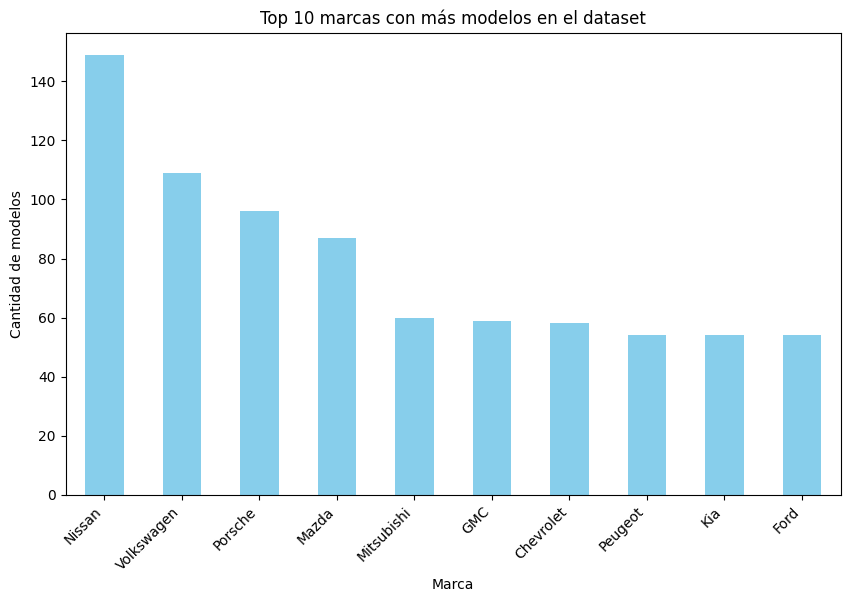

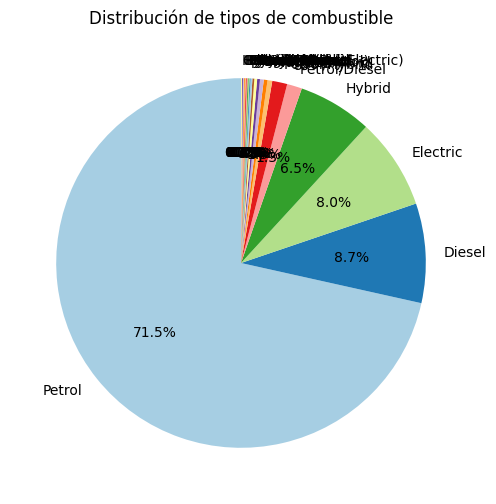

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


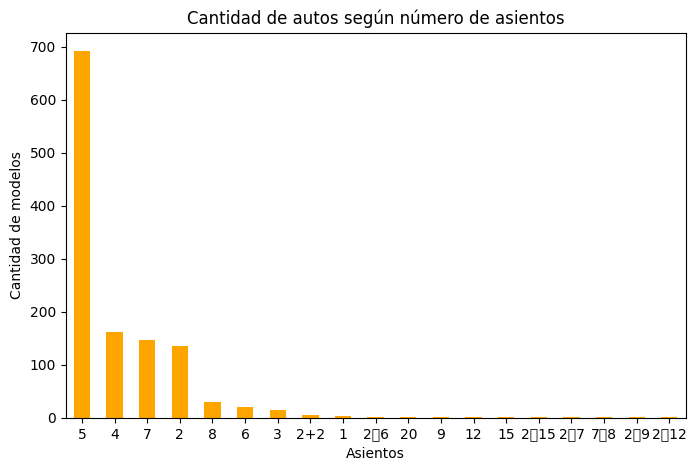

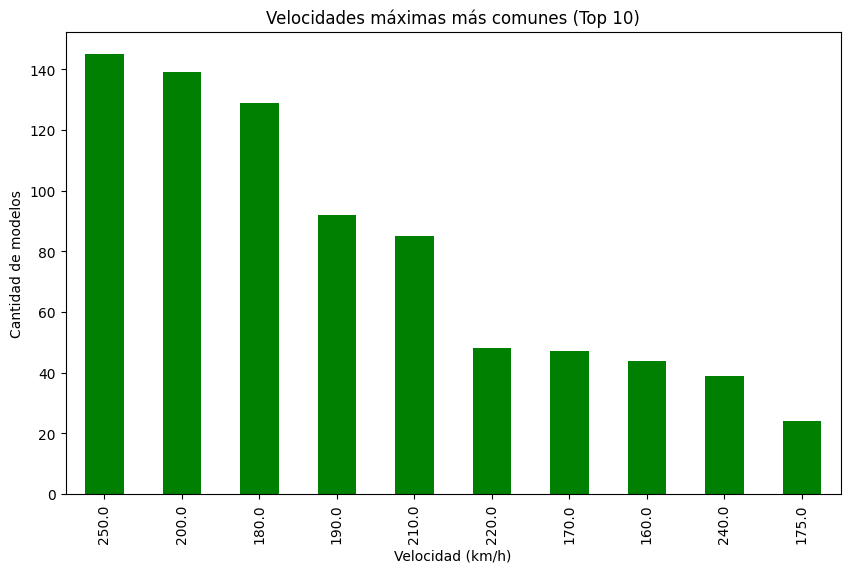

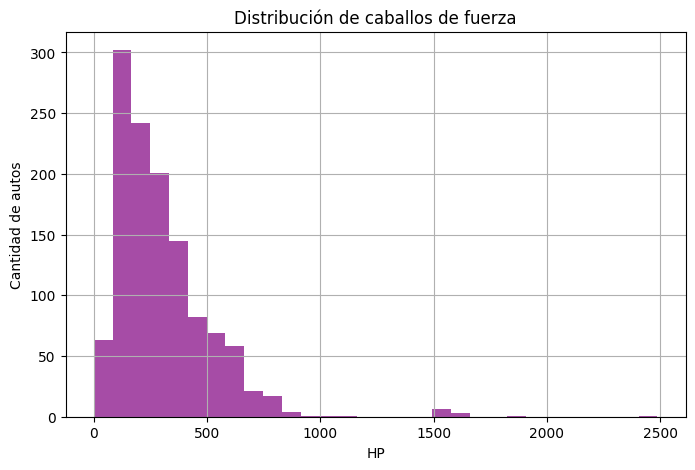

In [3]:
from google.colab import files
import pandas as pd

# Subir archivo desde tu PC (te pedirá seleccionarlo)
uploaded = files.upload()

# Luego lo cargas en un DataFrame
file_name = list(uploaded.keys())[0] # Get the uploaded file name

try:
  df = pd.read_csv(file_name, encoding='ISO-8859-1')  # Try ISO-8859-1 encoding
except UnicodeDecodeError:
  try:
    df = pd.read_csv(file_name, encoding='latin1') # Try latin1 encoding
  except UnicodeDecodeError:
    print("Could not decode the file using ISO-8859-1 or latin1. Please try another encoding.")
    df = None # Set df to None if decoding fails


# Ver primeras filas
if df is not None:
  display(df.head())

# Ver información general
if df is not None:
  display(df.info())

  import matplotlib.pyplot as plt

# ===============================
# 1. TOP 10 marcas con más modelos
# ===============================
top_companies = df['Company Names'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_companies.plot(kind='bar', color='skyblue')
plt.title("Top 10 marcas con más modelos en el dataset")
plt.xlabel("Marca")
plt.ylabel("Cantidad de modelos")
plt.xticks(rotation=45, ha='right')
plt.show()


# ===============================
# 2. Distribución de tipos de combustible
# ===============================
fuel_types = df['Fuel Types'].value_counts()

plt.figure(figsize=(6,6))
fuel_types.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title("Distribución de tipos de combustible")
plt.ylabel("")
plt.show()


# ===============================
# 3. Cantidad de autos por número de asientos
# ===============================
seat_counts = df['Seats'].value_counts()

plt.figure(figsize=(8,5))
seat_counts.plot(kind='bar', color='orange')
plt.title("Cantidad de autos según número de asientos")
plt.xlabel("Asientos")
plt.ylabel("Cantidad de modelos")
plt.xticks(rotation=0)
plt.show()


# ===============================
# 4. Velocidades máximas más comunes (TOP 10)
# ===============================
# Convertir velocidad a número quitando "km/h"
df['MaxSpeedNum'] = df['Total Speed'].str.replace(" km/h","", regex=False).str.strip()
df['MaxSpeedNum'] = pd.to_numeric(df['MaxSpeedNum'], errors='coerce')

top_speeds = df['MaxSpeedNum'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_speeds.plot(kind='bar', color='green')
plt.title("Velocidades máximas más comunes (Top 10)")
plt.xlabel("Velocidad (km/h)")
plt.ylabel("Cantidad de modelos")
plt.show()


# ===============================
# 5. Distribución de caballos de fuerza
# ===============================
# Extraer el primer número de HorsePower
df['HorsePowerNum'] = df['HorsePower'].str.extract(r'(\d+)').astype(float)

plt.figure(figsize=(8,5))
df['HorsePowerNum'].dropna().hist(bins=30, color='purple', alpha=0.7)
plt.title("Distribución de caballos de fuerza")
plt.xlabel("HP")
plt.ylabel("Cantidad de autos")
plt.show()